# Download and enrich CSV data

This notebook downloads journal CSVs from blob storage using Expidite `cloud_connector`, aggregates them into one DataFrame, and labels behaviour.

@@@ TODO: we should add a CSV file that contains the experimental data and then we can automatically enrich the raw data from the devices with this extra info to make analysis easy.

In [1]:
from pathlib import Path

import matplotlib.pyplot as plt
import pandas as pd
import seaborn as sns
from expidite_rpi.core import configuration as root_cfg
from expidite_rpi.core.cloud_connector import CloudConnector

Logging expidite to default file: C:\Users\bee-ops\AppData\Local\Temp\expidite\20260701T170909495\logs\default_20260701T170909505.log at level 20
2026-07-01 18:09:09,509 expidite INFO   [50812] Loading C:\Users\bee-ops\.expidite\system.cfg...


In [2]:
# Required config
AZURE_KEYS_FILE = Path.home() / ".expidite" / "keys_choiceassay.env"
assert AZURE_KEYS_FILE.exists(), f"Missing required config file: {AZURE_KEYS_FILE}"

CONTAINER_NAME = "expidite-journals"
TYPE_ID = "CAPOSE"

# Local download directory (relative to notebook working directory)
DOWNLOAD_DIR = Path("./downloads")
SRC_JOURNAL_DIR = DOWNLOAD_DIR / "src_journals"
SRC_JOURNAL_DIR.mkdir(parents=True, exist_ok=True)
aggregated_csv_file = DOWNLOAD_DIR / f"aggregated_{TYPE_ID}.csv"

PREFIX = f"V3_{TYPE_ID}"
SUFFIX = ".csv"

print(f"Downloading {PREFIX} files from '{CONTAINER_NAME}' to {DOWNLOAD_DIR.resolve()}")

## Utility display functions

In [3]:
# Display methods

# Use SNS to display a heatmap of a column of interest, e.g., Tube_prob_conf by device and date.
# We calculate the date from the timestamp column.
def display_heatmap(df, column, aggfunc="mean", title="Heatmap", fmt=".1f"):

    df["date"] = pd.to_datetime(df["timestamp"]).dt.date
    pivot_table = df.pivot_table(index="date", columns="device_name", values=column, aggfunc=aggfunc)

    plt.figure(figsize=(12, 8))
    # Set the font to 7
    sns.heatmap(pivot_table, annot=True, fmt=fmt, cmap="YlGnBu", annot_kws={"size": 7})
    plt.title(title)
    plt.ylabel("")
    plt.xlabel("")
    plt.show()


def display_heatmap_by_hour(df, column, aggfunc="mean", title="Heatmap", fmt=".1f"):

    df["hour"] = pd.to_datetime(df["timestamp"]).dt.floor("h")
    pivot_table = df.pivot_table(index="hour", columns="device_name", values=column, aggfunc=aggfunc)

    plt.figure(figsize=(12, 8))
    # Set the font to 7
    sns.heatmap(pivot_table, annot=True, fmt=fmt, cmap="YlGnBu", annot_kws={"size": 7})
    plt.title(title)
    plt.ylabel("")
    plt.xlabel("")
    plt.show()


def image_plot(df, x, y, title="Image Plot"):
    # Plot the L tube and R tube positions as a scatter plot, colored by device_name
    plt.figure(figsize=(12, 8))
    sns.scatterplot(
        data=df,
        x=x,
        y=y,
        hue="device_name",
        palette="tab10",
        # Use small markers with some transparency to avoid overplotting
        s=10,
        alpha=0.5,
    )
    plt.title(title)
    plt.xlabel(x)
    plt.ylabel(y)
    plt.ylim(0, 608)
    plt.xlim(0, 800)
    # Since this is image data, we plot the y axes in reverse order to match the image coordinates
    plt.gca().invert_yaxis()
    # Put the legend outside the plot area to the right
    plt.legend(title="Device Name", bbox_to_anchor=(1.05, 1), loc="upper left")
    plt.show()

## Download, combine and save journals (CSVs)

In [4]:
cc = CloudConnector.get_instance(root_cfg.CloudType.AZURE)
cc.set_keys(AZURE_KEYS_FILE)
files = cc.list_cloud_files(CONTAINER_NAME, prefix=PREFIX, suffix=SUFFIX)

print(f"Found {len(files)} matching CSV files in blobstore")
if files:
    cc.download_container(src_container=CONTAINER_NAME, dst_dir=SRC_JOURNAL_DIR, files=files, overwrite=False)
    print(f"Downloaded {len(files)} files to {SRC_JOURNAL_DIR.resolve()}")
else:
    print("No matching files to download.")

Found 789 matching CSV files in blobstore
2026-07-01 18:09:11,303 expidite INFO   [50812] Downloading total of 0 files
2026-07-01 18:09:11,306 expidite INFO   [50812] Completed downloaded of 0 files
Downloaded 789 files to C:\Users\bee-ops\code\ChoiceAssay\src\choice_assay\etl\downloads\src_journals


In [5]:
csv_paths = sorted(SRC_JOURNAL_DIR.rglob("*.csv"))
print(f"CSV files available locally: {len(csv_paths)}")

required_fields = [
    "device_id",
    "timestamp",
    "device_name",
    "Tube_prob_x",
    "Tube_prob_y",
    "Tube_prob_conf",
    "L_tube_x",
    "L_tube_y",
    "L_tube_conf",
    "R_tube_x",
    "R_tube_y",
    "R_tube_conf",
    "source_filename",
    "frame_index",
    "frame_start_time",
]

total_video_count = 0
total_videos_with_tube_conf = 0
df_list = []
for i, csv_path in enumerate(csv_paths):
    try:
        df = pd.read_csv(csv_path)
    except Exception as e:
        print(f"{i + 1}/{len(csv_paths)} Error reading {csv_path}: {e}")
        continue
    if not df.empty:
        if not all(field in df.columns for field in required_fields):
            print(
                f"{i + 1}/{len(csv_paths)} Warning: Missing required fields in {csv_path.name}. Skipping this file."
            )
            continue

        # Calculate the total number of unique source_filename values in the current CSV file
        unique_videos = df["source_filename"].nunique()
        total_video_count += unique_videos

        # Drop any rows where Tube_prob_conf is < 0.1
        # We do this early to avoid processing rows that we don't care about
        filtered_df = df[df["Tube_prob_conf"] >= 0.1]
        total_videos_with_tube_conf += filtered_df["source_filename"].nunique()
        print(f"Dropped {len(df) - len(filtered_df)} rows with Tube_prob_conf < 0.1")

        df_list.append(filtered_df)
        print(f"{i + 1}/{len(csv_paths)} Read {len(filtered_df)} rows from {csv_path.name}")

if df_list:
    aggregated_df = pd.concat(df_list, ignore_index=True)
else:
    aggregated_df = pd.DataFrame()

# To make processing faster and easier, we only want to retain the required columns
aggregated_df = aggregated_df[required_fields]

# Save as a single CSV file for further processing
aggregated_df.to_csv(aggregated_csv_file, index=False)

print(f"Aggregated CSV with {len(aggregated_df)} rows saved to: {aggregated_csv_file.resolve()}")
print(f"Total videos processed: {total_video_count}")
print(f"Total videos with Tube_prob_conf >= 0.1: {total_videos_with_tube_conf}")

# Create a csv that lists the file names of the unique source_filename values in the aggregated_df
unique_source_filenames = aggregated_df["source_filename"].unique()
unique_source_filenames_df = pd.DataFrame(unique_source_filenames, columns=["source_filename"])
unique_source_filenames_csv = DOWNLOAD_DIR / f"unique_source_filenames_{TYPE_ID}.csv"
unique_source_filenames_df.to_csv(unique_source_filenames_csv, index=False)
print(f"Unique source filenames CSV saved to: {unique_source_filenames_csv.resolve()}")

CSV files available locally: 789
1/789 Warning: Missing required fields in V3_CAPOSE_d83add1a11c5_20260326.csv. Skipping this file.
2/789 Warning: Missing required fields in V3_CAPOSE_d83add1a11c5_20260327.csv. Skipping this file.
3/789 Warning: Missing required fields in V3_CAPOSE_d83add1a11c5_20260329.csv. Skipping this file.
4/789 Warning: Missing required fields in V3_CAPOSE_d83add1a11c5_20260330.csv. Skipping this file.
5/789 Warning: Missing required fields in V3_CAPOSE_d83add1a11c5_20260331.csv. Skipping this file.
6/789 Warning: Missing required fields in V3_CAPOSE_d83add1a11c5_20260401.csv. Skipping this file.
7/789 Warning: Missing required fields in V3_CAPOSE_d83add1a11c5_20260402.csv. Skipping this file.
8/789 Warning: Missing required fields in V3_CAPOSE_d83add1a11c5_20260413.csv. Skipping this file.
9/789 Warning: Missing required fields in V3_CAPOSE_d83add1a11c5_20260414.csv. Skipping this file.
10/789 Warning: Missing required fields in V3_CAPOSE_d83add1a11c5_20260415.c

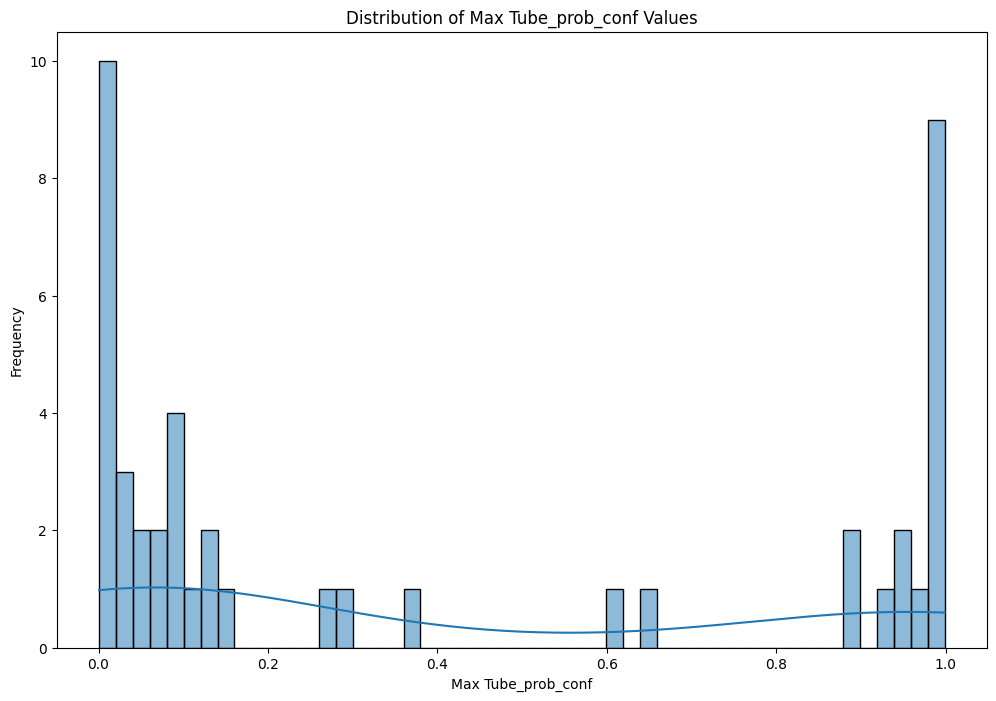

Proportion of videos with max Tube_prob_conf < 0.25: 31.25%
Proportion of videos with max Tube_prob_conf < 0.5: 35.00%
Proportion of videos with max Tube_prob_conf < 0.75: 37.50%


In [6]:
# Get the max Tube_prob_conf for each source_filename.
max_tube_prob_conf = df.groupby("source_filename")["Tube_prob_conf"].max().reset_index()

# Plot the distribution of max Tube_prob_conf values as a histogram
plt.figure(figsize=(12, 8))
sns.histplot(max_tube_prob_conf["Tube_prob_conf"], bins=50, kde=True)
plt.title("Distribution of Max Tube_prob_conf Values")
plt.xlabel("Max Tube_prob_conf")
plt.ylabel("Frequency")
plt.show()

# Print the proportion of videos with max Tube_prob_conf < 0.25, < 0.5, and < 0.75
total_videos = len(max_tube_prob_conf)
print(
    f"Proportion of videos with max Tube_prob_conf < 0.25: {(max_tube_prob_conf['Tube_prob_conf'] < 0.25).sum() / total_videos:.2%}"
)
print(
    f"Proportion of videos with max Tube_prob_conf < 0.5: {(max_tube_prob_conf['Tube_prob_conf'] < 0.5).sum() / total_videos:.2%}"
)
print(
    f"Proportion of videos with max Tube_prob_conf < 0.75: {(max_tube_prob_conf['Tube_prob_conf'] < 0.75).sum() / total_videos:.2%}"
)

## Enrich data

In [7]:
# Clean data
df = pd.read_csv(aggregated_csv_file)

# Set feeding to True if tube_prob_conf is greater than 0.5, otherwise set to False
df["feeding"] = df["Tube_prob_conf"] > 0.5
print(f"Set 'feeding' to True in {df['feeding'].sum()} rows, False in {len(df) - df['feeding'].sum()} rows")

# Extract the RPI number from the end of the device name (the characters after the last -)
df["rpi_number"] = df["device_name"].str.extract(r"-(\d+)$")
# Set the RPI type to 4 if the rpi_number is 10 or less
df["rpi_type"] = df["rpi_number"].apply(lambda x: "RPI4" if int(x) <= 10 else "RPI5")

Set 'feeding' to True in 169646 rows, False in 105112 rows


In [8]:
# How many rows don't have a high confidence feeding tube detection (L_tube_conf, R_tube_conf)
df["tube_low_confidence"] = (df["L_tube_conf"] < 0.25) | (df["R_tube_conf"] < 0.25)
print(f"Rows with low confidence feeding tube detection: {df['tube_low_confidence'].sum()}")

Rows with low confidence feeding tube detection: 44420


## Explore data - sanity checks

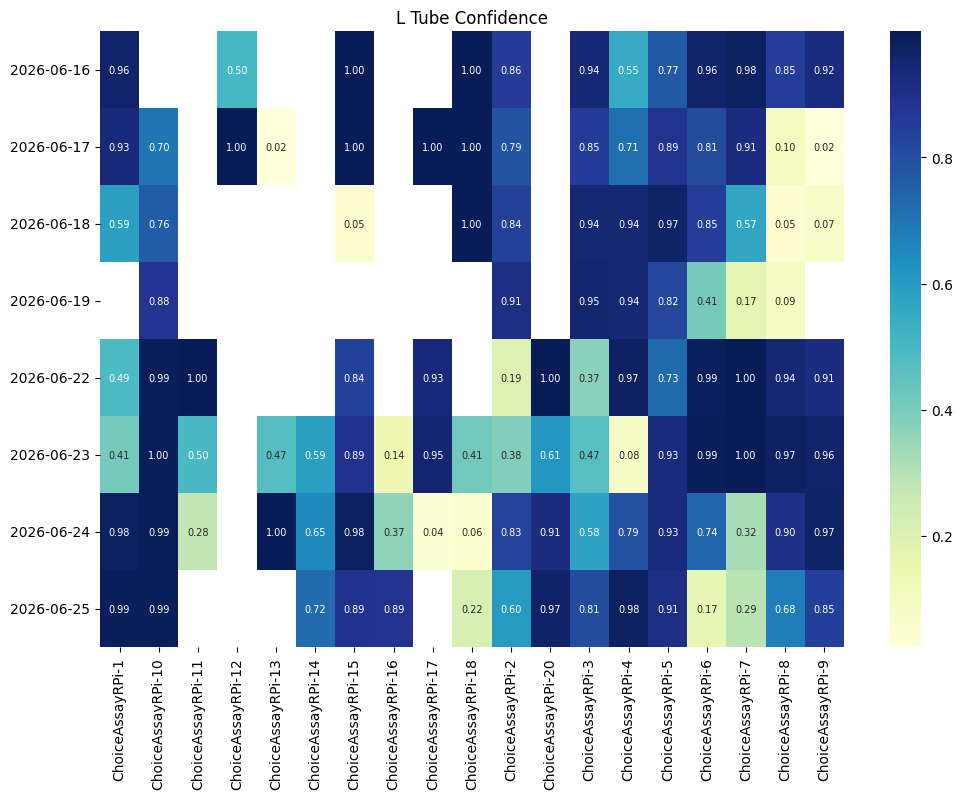

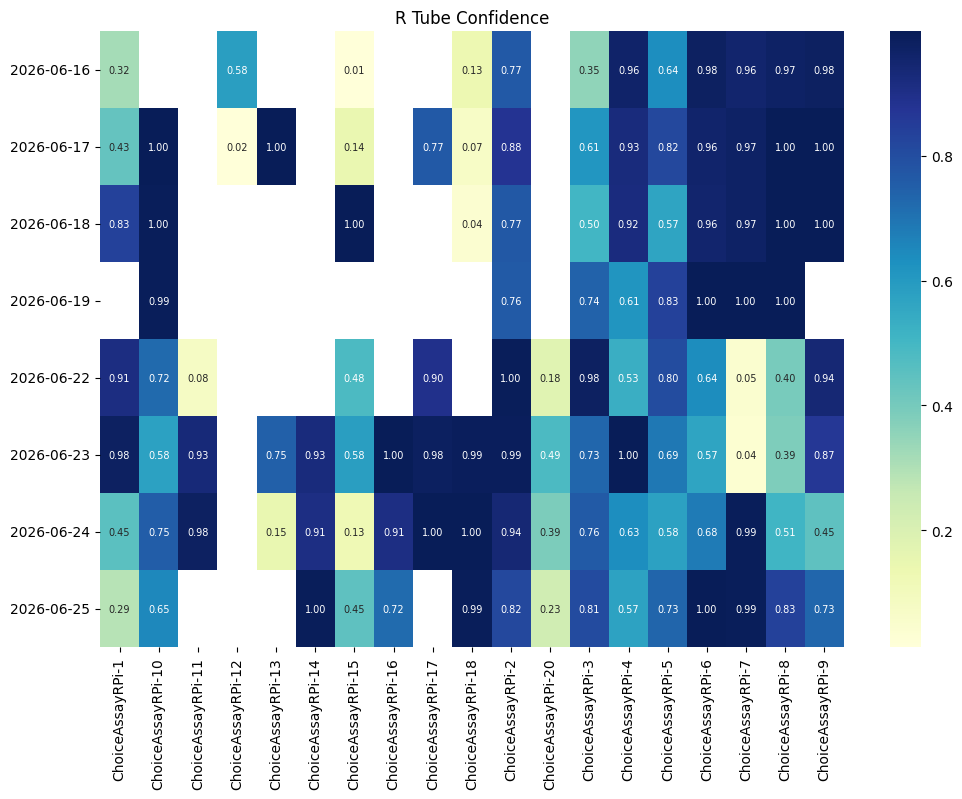

In [9]:
display_heatmap(df, "L_tube_conf", fmt=".2f", title="L Tube Confidence")
display_heatmap(df, "R_tube_conf", fmt=".2f", title="R Tube Confidence")

## Wandering bees

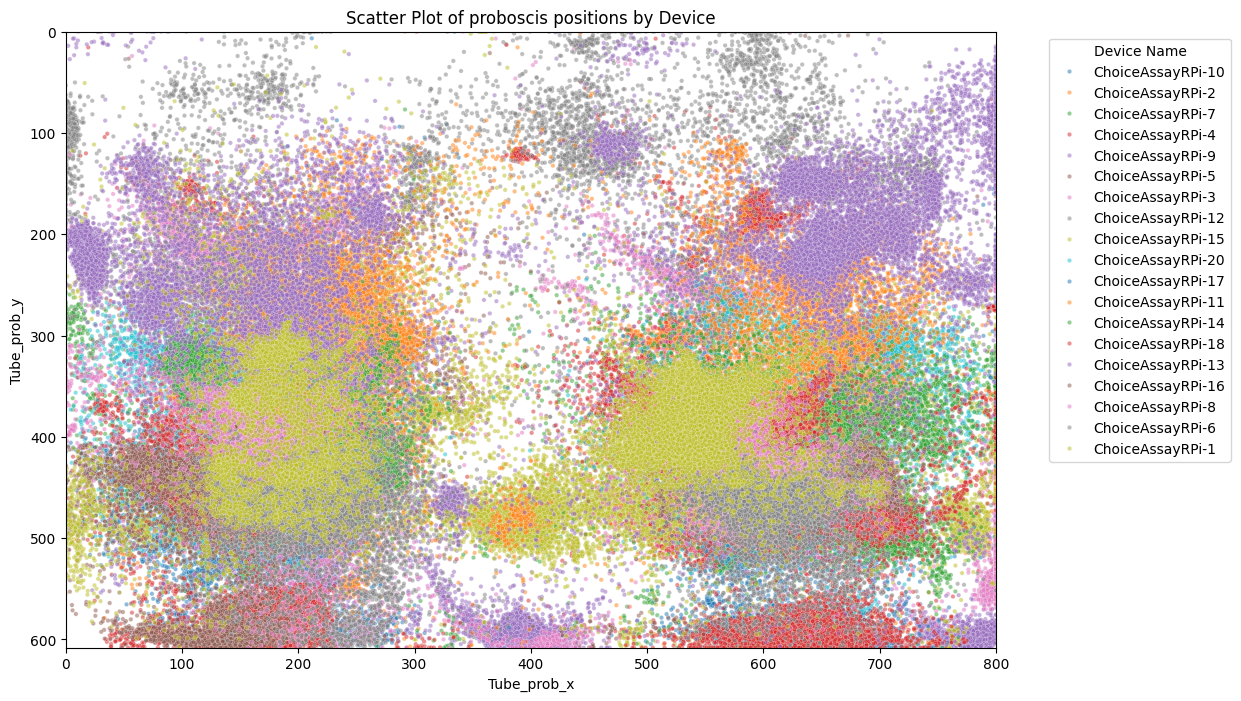

In [10]:
# Plot the XY of the Tube_prob as a scatter plot, colored by device_name
image_plot(df, "Tube_prob_x", "Tube_prob_y", title="Scatter Plot of proboscis positions by Device")

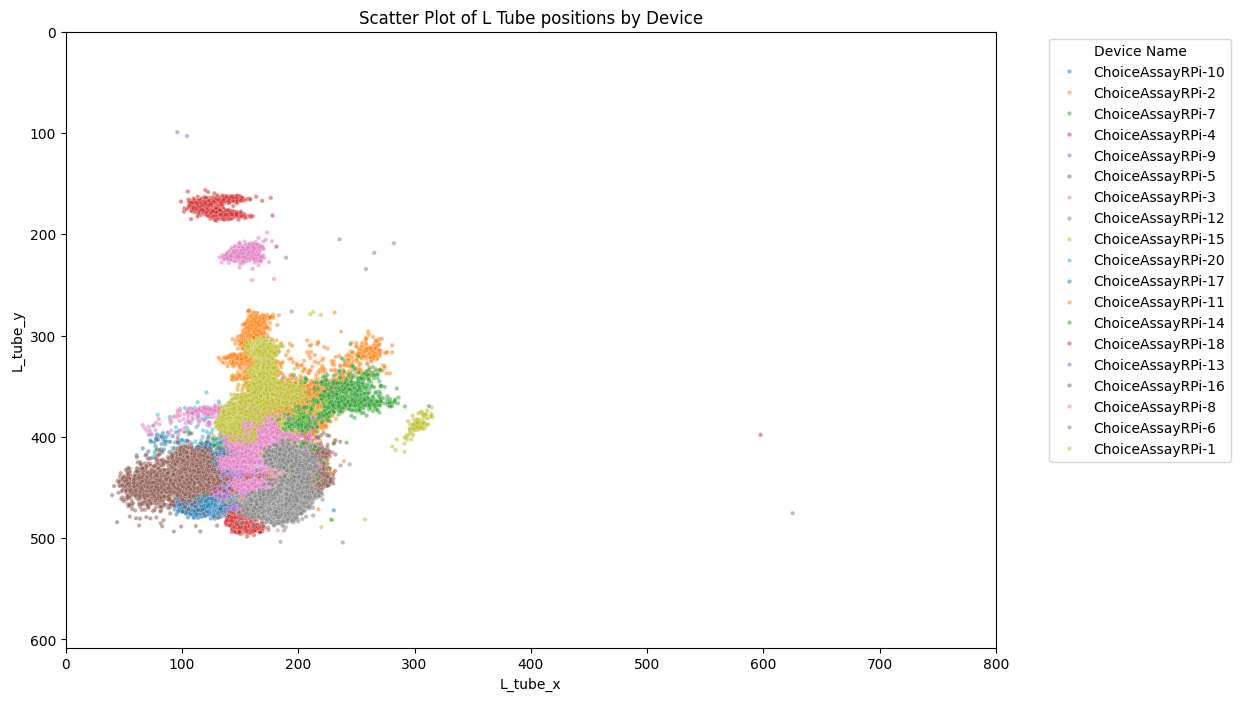

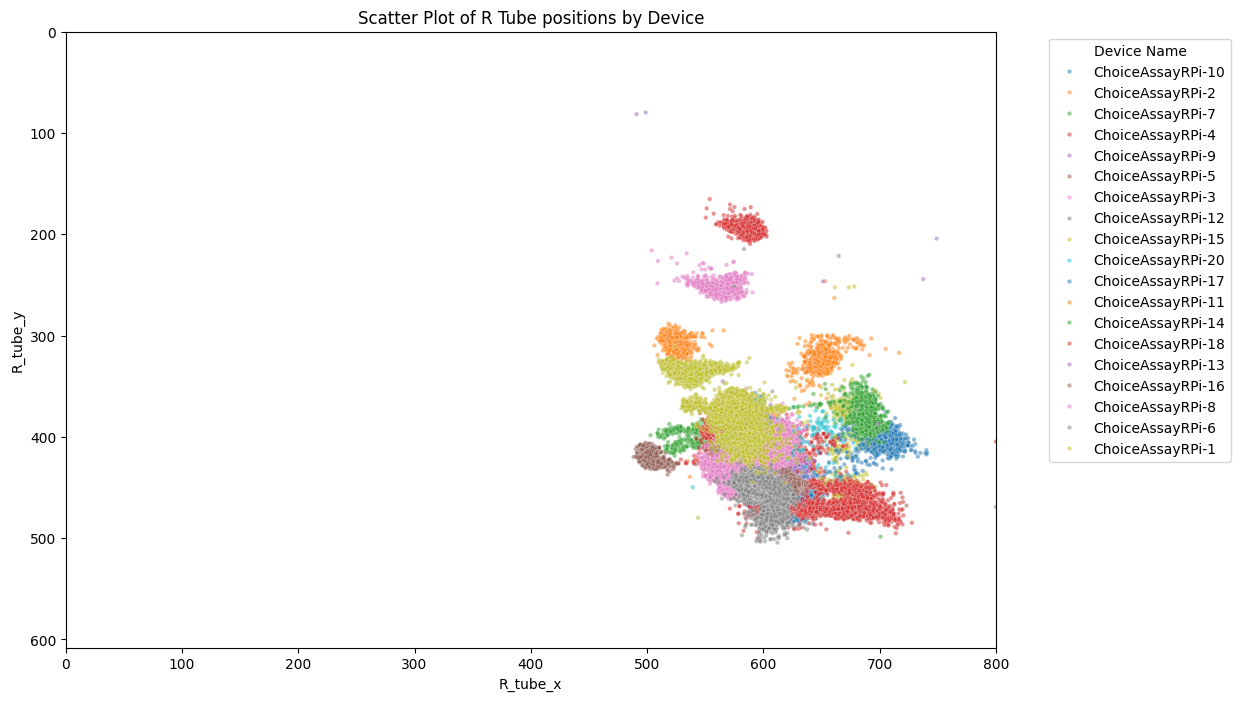

In [11]:
image_plot(df, "L_tube_x", "L_tube_y", title="Scatter Plot of L Tube positions by Device")
image_plot(df, "R_tube_x", "R_tube_y", title="Scatter Plot of R Tube positions by Device")

## Actual feeding data review

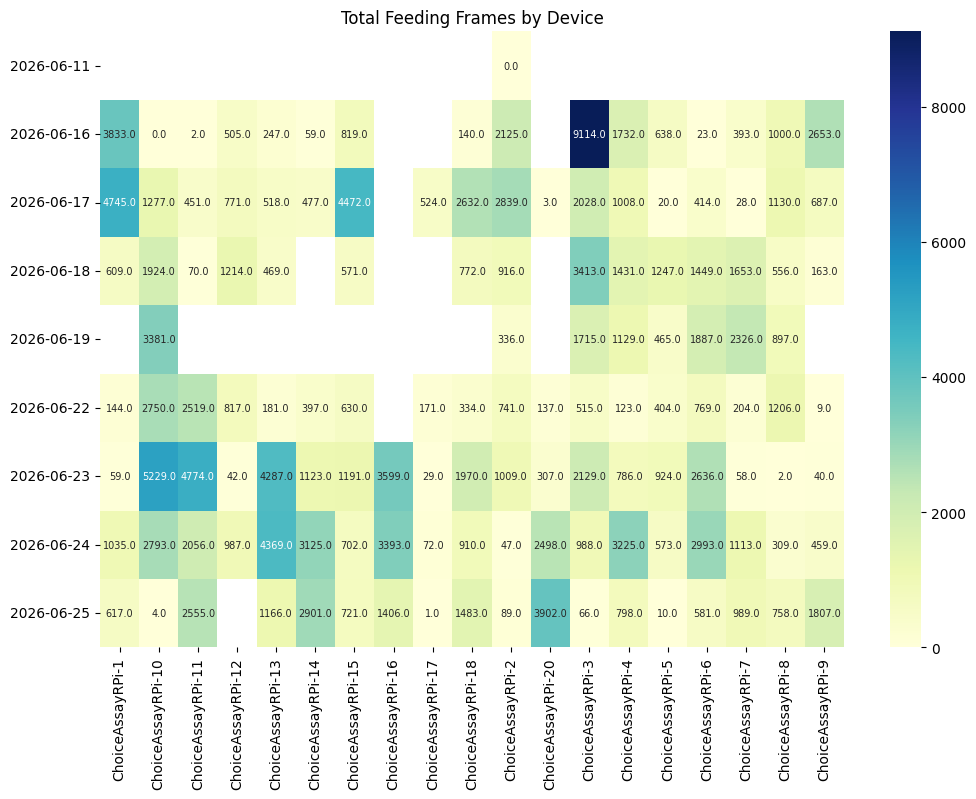

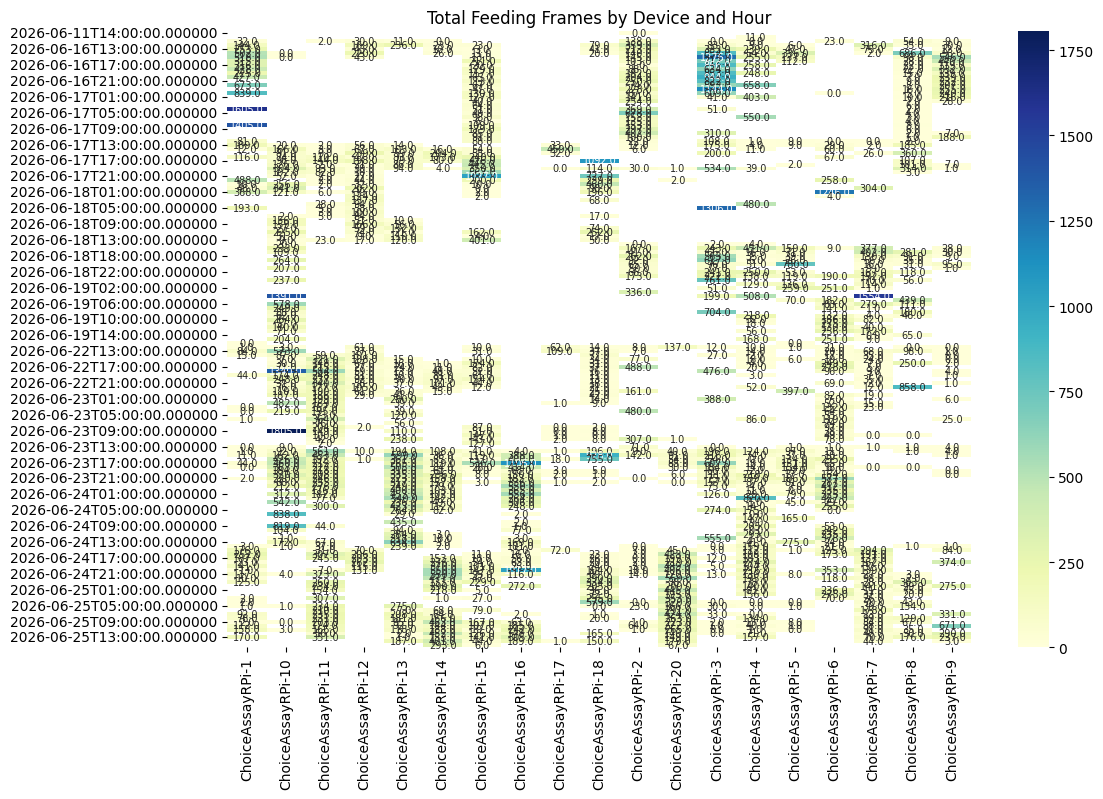

In [12]:
# Display a heatmap of the total feeding frames by device and date
display_heatmap(df, "feeding", "sum", "Total Feeding Frames by Device")
display_heatmap_by_hour(df, "feeding", "sum", "Total Feeding Frames by Device and Hour")